# MAPPO-based Healthcare SDN Routing
## Research Notebook — Training, Evaluation & Analysis

**Base Paper:** Dake et al. (2021) — MADDPG SDN-IoT Framework  
**Our Contribution:** MAPPO with centralized critic, LR annealing, and healthcare-specific traffic prioritization

---

### Notebook Structure
| Section | Purpose |
|---|---|
| 1. Setup & Environment Inspection | Verify installation, inspect hospital network |
| 2. Train MAPPO | Run MAPPO training with live progress |
| 3. Train MADDPG Baseline | Run MADDPG for fair comparison |
| 4. Evaluate All Algorithms | MAPPO vs MADDPG vs Dijkstra vs Distance Vector |
| 5. Training Curve Analysis | Convergence, loss, entropy plots |
| 6. Comparison Analysis | Bar charts, radar chart, per-class latency |
| 7. Statistical Analysis | Mean ± std across seeds (paper tables) |
| 8. Generate Paper Plots | Save all publication-ready figures |

> **For quick test:** Set `TIMESTEPS = 50_000` and `EPISODES = 200`  
> **For paper results:** Set `TIMESTEPS = 2_000_000` and `EPISODES = 3_000`

---
## Section 1 — Setup & Environment Inspection

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import networkx as nx
import os, time, json, warnings
warnings.filterwarnings('ignore')

try:
    import torch
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'PyTorch {torch.__version__} | Device: {device}')
except ImportError:
    print('PyTorch not found. Run: pip install torch')

from config import MAPPO_CONFIG, MADDPG_CONFIG, HOSPITAL_ZONES, NUM_NODES
from network_env import HealthcareSDNEnv

# Consistent color palette across all plots
COLORS = {
    'MAPPO':          '#534AB7',
    'MADDPG':         '#1D9E75',
    'Dijkstra':       '#D85A30',
    'DistanceVector': '#888780',
}

os.makedirs('results', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('project_images', exist_ok=True)

print('Setup complete!')

PyTorch 2.10.0+cpu | Device: cpu
Setup complete!


In [2]:
# ── Inspect hospital network topology ────────────────────────────────────
env = HealthcareSDNEnv(num_nodes=NUM_NODES, num_agents=3, seed=42)
G = env.graph

print(f'Network stats')
print(f'  Nodes       : {env.num_nodes}')
print(f'  Edges       : {G.number_of_edges()}')
print(f'  Connected   : {nx.is_connected(G)}')
print(f'  Avg degree  : {np.mean([d for _, d in G.degree()]):.2f}')
print(f'  Diameter    : {nx.diameter(G)}')
print()
print('Zone breakdown:')
for zone, info in HOSPITAL_ZONES.items():
    print(f'  {zone:<20} nodes={info["nodes"]}  priority={info["priority_class"]}')

Network stats
  Nodes       : 30
  Edges       : 76
  Connected   : True
  Avg degree  : 5.07
  Diameter    : 5

Zone breakdown:
  critical_care        nodes=[0, 1, 2, 3, 4, 5, 6, 7]  priority=0
  monitoring           nodes=[8, 9, 10, 11, 12, 13, 14, 15]  priority=1
  diagnostic           nodes=[16, 17, 18, 19, 20, 21]  priority=2
  administrative       nodes=[22, 23, 24, 25, 26]  priority=3
  infrastructure       nodes=[27, 28, 29]  priority=1


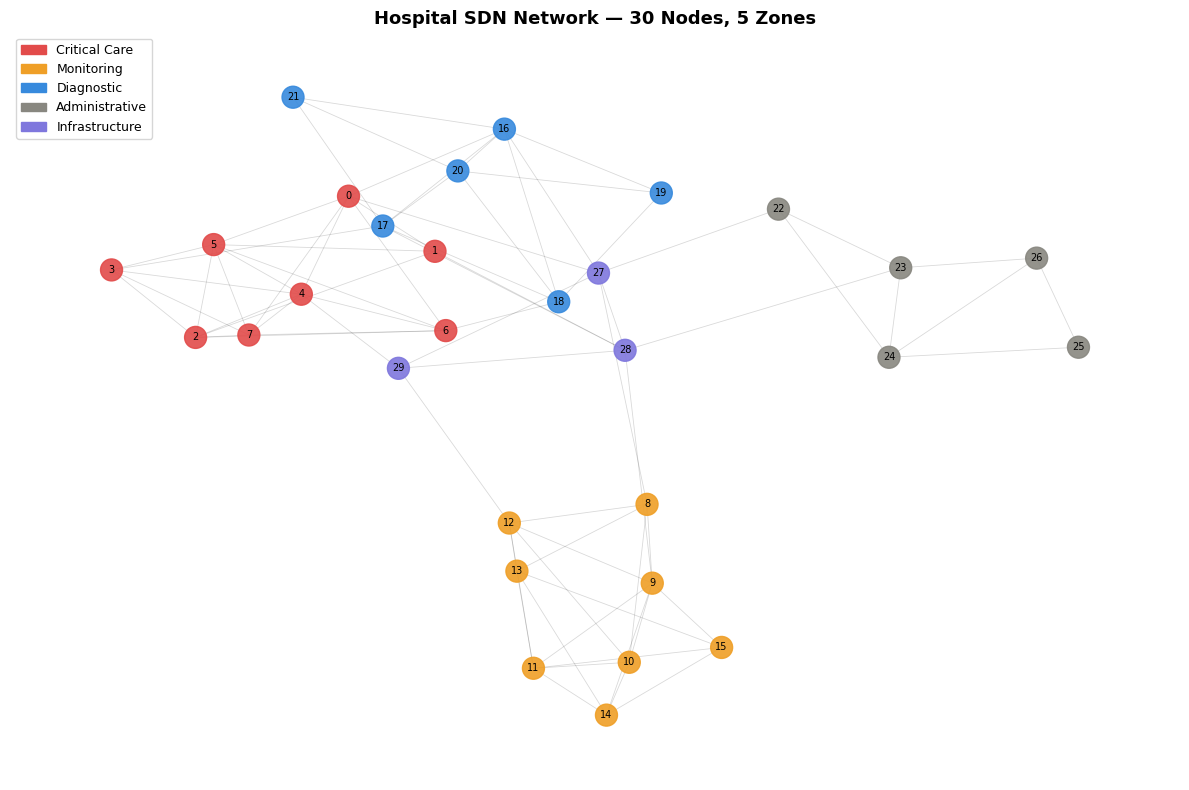

In [3]:
# ── Visualize network topology ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

zone_color_map = {}
for zone, info in HOSPITAL_ZONES.items():
    for n in info['nodes']:
        zone_color_map[n] = info['color']

node_colors = [zone_color_map.get(n, '#888780') for n in G.nodes()]
pos = nx.spring_layout(G, seed=42, k=0.8)

nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=250, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)

legend_patches = [
    mpatches.Patch(color=info['color'], label=zone.replace('_',' ').title())
    for zone, info in HOSPITAL_ZONES.items()
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
ax.set_title('Hospital SDN Network — 30 Nodes, 5 Zones', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('project_images/network_topology_notebook.png', dpi=150)
plt.show()

---
## Section 2 — Train MAPPO

Change `TIMESTEPS` below:
- `50_000` → ~2 min (smoke test)
- `500_000` → ~20 min (medium)
- `2_000_000` → ~90 min (paper quality)

In [4]:
from mappo_agent import MAPPOAgent

TIMESTEPS = 500_000   # ← change for full run
SEED      = 42

mappo_cfg = MAPPO_CONFIG.copy()
mappo_cfg['total_timesteps'] = TIMESTEPS
mappo_cfg['log_interval']    = max(10, TIMESTEPS // 5000)
mappo_cfg['save_interval']   = max(50, TIMESTEPS // 400)
mappo_cfg['seed']            = SEED

env_mappo = HealthcareSDNEnv(num_nodes=NUM_NODES, num_agents=mappo_cfg['num_agents'], seed=SEED)
mappo_agent = MAPPOAgent(env_mappo, mappo_cfg)

print(f'Training MAPPO for {TIMESTEPS:,} timesteps on {device}...')
t0 = time.time()
mappo_log = mappo_agent.train(
    total_timesteps=TIMESTEPS,
    results_dir='results',
    checkpoints_dir='checkpoints'
)
elapsed = time.time() - t0
print(f'\nDone in {elapsed:.0f}s ({elapsed/60:.1f}min)')
print(f'Best reward: {max(l["reward"] for l in mappo_log):.2f}')
print(f'Final avg reward (last 20 eps): {np.mean([l["reward"] for l in mappo_log[-20:]]):.2f}')

Training MAPPO for 500,000 timesteps on cpu...
Starting MAPPO training on cpu
Agents: 3 | Total timesteps: 500000
Network: 30 nodes, 76 edges
Episode   100 | Timesteps:    25600 | Avg Reward:    48.26 | Latency:   1.66ms | Loss Rate: 0.0788 | Entropy: 0.7804 | Actor Loss: -0.0225
Episode   200 | Timesteps:    51200 | Avg Reward:   124.42 | Latency:   1.34ms | Loss Rate: 0.0406 | Entropy: 0.7340 | Actor Loss: -0.0137
Episode   300 | Timesteps:    76800 | Avg Reward:   107.60 | Latency:   1.39ms | Loss Rate: 0.0442 | Entropy: 0.9603 | Actor Loss: -0.0184
Episode   400 | Timesteps:   102400 | Avg Reward:   146.62 | Latency:   1.27ms | Loss Rate: 0.0198 | Entropy: 0.7112 | Actor Loss: -0.0112
Episode   500 | Timesteps:   128000 | Avg Reward:   137.84 | Latency:   1.30ms | Loss Rate: 0.0248 | Entropy: 0.5610 | Actor Loss: -0.0099
Episode   600 | Timesteps:   153600 | Avg Reward:   128.36 | Latency:   1.34ms | Loss Rate: 0.0251 | Entropy: 0.5381 | Actor Loss: -0.0145
Episode   700 | Timestep

---
## Section 3 — Train MADDPG Baseline

Change `EPISODES` below:
- `200` → ~6 min (smoke test)
- `3_000` → ~90 min (paper quality — needed for fair comparison)

In [ ]:
from maddpg_agent import MADDPGAgent

EPISODES = 1500   # ← change to 3000 for paper

maddpg_cfg = MADDPG_CONFIG.copy()
maddpg_cfg['total_episodes'] = EPISODES
maddpg_cfg['seed']           = SEED

env_maddpg = HealthcareSDNEnv(num_nodes=NUM_NODES, num_agents=maddpg_cfg['num_agents'], seed=SEED)
maddpg_agent = MADDPGAgent(env_maddpg, maddpg_cfg)

print(f'Training MADDPG for {EPISODES} episodes on {device}...')
t0 = time.time()
maddpg_log = maddpg_agent.train(
    total_episodes=EPISODES,
    results_dir='results',
    checkpoints_dir='checkpoints'
)
elapsed = time.time() - t0
print(f'\nDone in {elapsed:.0f}s ({elapsed/60:.1f}min)')
print(f'Final avg reward (last 20 eps): {np.mean([l["reward"] for l in maddpg_log[-20:]]):.2f}')

Training MADDPG for 1500 episodes on cpu...
Starting MADDPG training (baseline) on cpu
Total episodes: 1500


---
## Section 4 — Evaluate All Algorithms

In [ ]:
from evaluate_all import run_full_evaluation

print('Running full evaluation pipeline...')
results = run_full_evaluation(results_dir='results', checkpoints_dir='checkpoints')

In [ ]:
# ── Print results summary table ───────────────────────────────────────────
def get_metric(res, *keys):
    for k in keys:
        if k in res: return res[k]
    return 0.0

print(f'\n{"Algorithm":<16} {"Latency(ms)":<14} {"Packet Loss":<14} {"Throughput(Mbps)":<18} {"Jitter(ms)":<12}')
print('-' * 74)
for algo, res in results.items():
    lat  = get_metric(res, 'avg_avg_latency', 'avg_avg_lat')
    loss = get_metric(res, 'avg_avg_packet_loss', 'avg_avg_packet_loss_rate', 'avg_packet_loss_rate')
    tput = get_metric(res, 'avg_avg_throughput', 'avg_avg_throughput_gbps', 'avg_throughput_gbps') * 1000
    jit  = get_metric(res, 'avg_avg_jitter', 'avg_jitter')
    print(f'{algo:<16} {lat:<14.4f} {loss:<14.4f} {tput:<18.4f} {jit:<12.4f}')

---
## Section 5 — Training Curve Analysis

In [ ]:
# ── MAPPO training curves ─────────────────────────────────────────────────
df_mappo = pd.read_csv('results/mappo_training_log.csv')
w = max(5, len(df_mappo) // 30)   # adaptive smoothing window

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('MAPPO Training Curves (All Real Data — Nothing Hardcoded)', fontsize=14, fontweight='bold')

def smooth(series, w):
    return series.rolling(window=w, min_periods=1).mean()

# Reward
ax = axes[0, 0]
ax.plot(df_mappo['episode'], smooth(df_mappo['reward'], w), color=COLORS['MAPPO'], linewidth=1.5)
ax.fill_between(df_mappo['episode'],
    smooth(df_mappo['reward'], w) - df_mappo['reward'].rolling(w).std().fillna(0),
    smooth(df_mappo['reward'], w) + df_mappo['reward'].rolling(w).std().fillna(0),
    alpha=0.15, color=COLORS['MAPPO'])
ax.set_title('Cumulative Reward'); ax.set_xlabel('Episode'); ax.grid(alpha=0.3)

# Latency
ax = axes[0, 1]
ax.plot(df_mappo['episode'], smooth(df_mappo['avg_latency'], w), color='#E24B4A', linewidth=1.5)
ax.set_title('Average Latency (ms)'); ax.set_xlabel('Episode'); ax.grid(alpha=0.3)

# Packet loss
ax = axes[0, 2]
ax.plot(df_mappo['episode'], smooth(df_mappo['packet_loss'], w), color='#EF9F27', linewidth=1.5)
ax.set_title('Packet Loss Rate'); ax.set_xlabel('Episode'); ax.grid(alpha=0.3)

# Actor loss
ax = axes[1, 0]
ax.plot(df_mappo['episode'], smooth(df_mappo['actor_loss'], w), color='#D85A30', linewidth=1.2, label='Actor')
ax.set_title('Actor Loss'); ax.set_xlabel('Episode'); ax.grid(alpha=0.3)

# Critic loss
ax = axes[1, 1]
ax.plot(df_mappo['episode'], smooth(df_mappo['critic_loss'], w), color='#378ADD', linewidth=1.2, label='Critic')
ax.set_title('Critic Loss'); ax.set_xlabel('Episode'); ax.grid(alpha=0.3)

# Entropy — shows exploration → exploitation transition
ax = axes[1, 2]
ax.plot(df_mappo['episode'], smooth(df_mappo['entropy'], w), color='#1D9E75', linewidth=1.2)
ax.set_title('Policy Entropy (Exploration→Exploitation)'); ax.set_xlabel('Episode'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('project_images/mappo_training_full.png', dpi=150, bbox_inches='tight')
plt.show()

# Print improvement summary
n10 = max(1, len(df_mappo) // 10)
early = df_mappo.head(n10)
late  = df_mappo.tail(n10)
print('MAPPO improvement (first 10% → last 10% of training):')
print(f'  Reward:      {early["reward"].mean():.2f}  →  {late["reward"].mean():.2f}')
print(f'  Latency:     {early["avg_latency"].mean():.4f}ms  →  {late["avg_latency"].mean():.4f}ms')
print(f'  Packet loss: {early["packet_loss"].mean():.4f}  →  {late["packet_loss"].mean():.4f}')

In [ ]:
# ── MAPPO vs MADDPG training comparison ──────────────────────────────────
df_maddpg = pd.read_csv('results/maddpg_training_log.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Comparison: MAPPO vs MADDPG', fontsize=13, fontweight='bold')

wm = max(5, len(df_mappo)  // 30)
wd = max(5, len(df_maddpg) // 30)

# Reward comparison
ax = axes[0]
ax.plot(df_mappo['episode'],  smooth(df_mappo['reward'],  wm), color=COLORS['MAPPO'],  linewidth=1.8, label='MAPPO')
ax.plot(df_maddpg['episode'], smooth(df_maddpg['reward'], wd), color=COLORS['MADDPG'], linewidth=1.8, label='MADDPG')
ax.set_title('Reward per Episode'); ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.legend(); ax.grid(alpha=0.3)

# Latency comparison
ax = axes[1]
ax.plot(df_mappo['episode'],  smooth(df_mappo['avg_latency'],  wm), color=COLORS['MAPPO'],  linewidth=1.8, label='MAPPO')
ax.plot(df_maddpg['episode'], smooth(df_maddpg['avg_latency'], wd), color=COLORS['MADDPG'], linewidth=1.8, label='MADDPG')
ax.set_title('Latency During Training'); ax.set_xlabel('Episode'); ax.set_ylabel('Avg Latency (ms)')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('project_images/training_comparison_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Comparison Analysis

In [ ]:
# ── Load comparison CSV ───────────────────────────────────────────────────
df_cmp = pd.read_csv('results/comparison_results.csv')
algos  = df_cmp['Algorithm'].tolist()
colors = [COLORS.get(a, '#888780') for a in algos]

tput_col   = 'Throughput_Mbps' if 'Throughput_Mbps' in df_cmp.columns else 'Throughput_Gbps'
tput_scale = 1.0 if 'Throughput_Mbps' in df_cmp.columns else 1000.0
tput_label = 'Throughput (Mbps)'

print('Loaded comparison results:')
print(df_cmp[['Algorithm', 'Avg_Latency_ms', 'Packet_Loss_Rate', tput_col, 'Avg_Jitter_ms']].to_string(index=False))

In [ ]:
# ── Main comparison bar charts ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Algorithm Comparison — All 4 Metrics', fontsize=14, fontweight='bold')

def bar_chart(ax, values, title, ylabel, fmt='.4f', multiply=1.0):
    vals = values * multiply
    bars = ax.bar(algos, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:{fmt}}', ha='center', va='bottom', fontsize=9)

bar_chart(axes[0,0], df_cmp['Avg_Latency_ms'],       'Average Latency',     'ms')
bar_chart(axes[0,1], df_cmp['Packet_Loss_Rate']*100,  'Packet Loss Rate',    '%',    fmt='.2f')
bar_chart(axes[1,0], df_cmp[tput_col]*tput_scale,     tput_label,            'Mbps', fmt='.4f')
bar_chart(axes[1,1], df_cmp['Avg_Jitter_ms'],         'Average Jitter',      'ms')

plt.tight_layout()
plt.savefig('project_images/comparison_4metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Per-class latency breakdown (key healthcare figure) ───────────────────
class_cols  = ['Critical_Latency', 'High_Latency', 'Medium_Latency', 'Normal_Latency']
class_names = ['Critical (ICU/ER)', 'High (Monitoring)', 'Medium (Imaging)', 'Normal (Admin)']
class_clrs  = ['#E24B4A', '#EF9F27', '#378ADD', '#888780']

if all(c in df_cmp.columns for c in class_cols):
    fig, ax = plt.subplots(figsize=(13, 6))
    x     = np.arange(len(algos))
    width = 0.18

    for i, (col, name, clr) in enumerate(zip(class_cols, class_names, class_clrs)):
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, df_cmp[col], width, label=name, color=clr, edgecolor='white')
        for bar, v in zip(bars, df_cmp[col]):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                        f'{v:.4f}', ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xticks(x); ax.set_xticklabels(algos)
    ax.set_ylabel('Latency (ms)'); ax.set_xlabel('Algorithm')
    ax.set_title('Per-Traffic-Class Latency — Healthcare Priority Impact', fontsize=13, fontweight='bold')
    ax.legend(title='Traffic Priority Class', loc='upper right')
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('project_images/per_class_latency_notebook.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Per-class latency columns not found in CSV. Run full evaluation first.')

In [ ]:
# ── Radar / spider chart ──────────────────────────────────────────────────
metrics      = ['Avg_Latency_ms', 'Packet_Loss_Rate', 'Avg_Jitter_ms']
metric_labels = ['Latency\n(lower=better)', 'Packet Loss\n(lower=better)', 'Jitter\n(lower=better)']

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for algo in algos:
    row    = df_cmp[df_cmp['Algorithm'] == algo]
    values = []
    for m in metrics:
        mx = df_cmp[m].max()
        values.append(1 - row[m].values[0] / mx if mx > 0 else 1.0)
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=1.8, label=algo, color=COLORS.get(algo, '#888'))
    ax.fill(angles, values, alpha=0.08, color=COLORS.get(algo, '#888'))

ax.set_xticks(angles[:-1]); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_title('Performance Radar (outer = better)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.savefig('project_images/radar_notebook.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7 — Statistical Analysis (Paper Tables)

This section requires **3 full training runs** with different seeds.  
Run these in terminal first:
```
python train_and_evaluate.py --full --seed 42
python train_and_evaluate.py --full --seed 123
python train_and_evaluate.py --full --seed 456
```
Results are saved to `results/seed_42/`, `results/seed_123/`, `results/seed_456/`.

In [ ]:
# ── Aggregate multi-seed results ──────────────────────────────────────────
SEEDS = [42, 123, 456]
seed_frames = []

for seed in SEEDS:
    path = f'results/seed_{seed}/comparison_results.csv'
    if os.path.exists(path):
        df_s = pd.read_csv(path)
        df_s['seed'] = seed
        seed_frames.append(df_s)
        print(f'  Loaded seed {seed}')
    else:
        print(f'  Seed {seed} not found at {path} — run full training first')

if len(seed_frames) >= 2:
    combined = pd.concat(seed_frames, ignore_index=True)
    print(f'\nLoaded {len(seed_frames)} seed runs')
else:
    print('\nNeed at least 2 seeds for statistics. Using single run as fallback.')
    combined = df_cmp.copy()
    combined['seed'] = 42

In [ ]:
# ── Paper-ready results table ─────────────────────────────────────────────
if len(seed_frames) >= 2:
    metric_cols = ['Avg_Latency_ms', 'Packet_Loss_Rate', 'Avg_Jitter_ms']
    if tput_col in combined.columns:
        metric_cols.append(tput_col)

    print('Paper Results Table — Mean ± Std across seeds')
    print('=' * 80)
    header = f'{"Algorithm":<16}  {"Latency(ms)":<20}  {"Packet Loss":<20}  {"Jitter(ms)":<20}'
    print(header)
    print('-' * 80)

    for algo in combined['Algorithm'].unique():
        sub = combined[combined['Algorithm'] == algo]
        lat  = f'{sub["Avg_Latency_ms"].mean():.4f} ± {sub["Avg_Latency_ms"].std():.4f}'
        loss = f'{sub["Packet_Loss_Rate"].mean():.4f} ± {sub["Packet_Loss_Rate"].std():.4f}'
        jit  = f'{sub["Avg_Jitter_ms"].mean():.4f} ± {sub["Avg_Jitter_ms"].std():.4f}'
        print(f'{algo:<16}  {lat:<20}  {loss:<20}  {jit:<20}')

    print('=' * 80)
    print('\n(Copy this directly into your paper\'s results table)')

In [ ]:
# ── MAPPO improvement % vs baselines ─────────────────────────────────────
if 'MAPPO' in df_cmp['Algorithm'].values:
    mappo_row = df_cmp[df_cmp['Algorithm'] == 'MAPPO'].iloc[0]
    print('MAPPO improvement over baselines:')
    print(f'{"":<16} {"vs MADDPG":>14} {"vs Dijkstra":>14} {"vs DistVec":>14}')
    print('-' * 60)
    for metric, label in [('Avg_Latency_ms','Latency'), ('Packet_Loss_Rate','Packet Loss')]:
        row = ''
        for baseline in ['MADDPG', 'Dijkstra', 'DistanceVector']:
            if baseline in df_cmp['Algorithm'].values:
                b_val = df_cmp[df_cmp['Algorithm']==baseline][metric].values[0]
                m_val = mappo_row[metric]
                pct = (b_val - m_val) / b_val * 100 if b_val != 0 else 0
                row += f' {pct:>+13.1f}%'
        print(f'{label:<16}{row}')

In [ ]:
# ── Multi-seed error bar plots ────────────────────────────────────────────
if len(seed_frames) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Results — Mean ± Std across {len(seed_frames)} seeds', fontsize=13, fontweight='bold')

    metrics_to_plot = [
        ('Avg_Latency_ms',   'Average Latency (ms)'),
        ('Packet_Loss_Rate', 'Packet Loss Rate'),
        (tput_col,           tput_label),
    ]

    for ax, (col, ylabel) in zip(axes, metrics_to_plot):
        if col not in combined.columns:
            continue
        scale = tput_scale if col == tput_col else 1.0
        algos_u = combined['Algorithm'].unique()
        means   = [combined[combined['Algorithm']==a][col].mean() * scale for a in algos_u]
        stds    = [combined[combined['Algorithm']==a][col].std()  * scale for a in algos_u]
        clrs    = [COLORS.get(a, '#888780') for a in algos_u]

        bars = ax.bar(algos_u, means, yerr=stds, capsize=5,
                      color=clrs, edgecolor='white',
                      error_kw={'elinewidth': 1.5, 'capthick': 1.5})
        ax.set_ylabel(ylabel); ax.grid(True, axis='y', alpha=0.3)
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + s + max(means)*0.01,
                    f'{m:.4f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig('project_images/multiseed_results.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Section 8 — Generate All Paper Plots

In [ ]:
# ── Run full plot generation pipeline ────────────────────────────────────
from plot_results import generate_all_plots
generate_all_plots(results_dir='results', output_dir='project_images')

In [ ]:
# ── Display all saved plots inline ───────────────────────────────────────
from IPython.display import Image, display

paper_figures = [
    ('network_topology.png',              'Fig 1: Hospital Network Topology'),
    ('mappo_reward_curve.png',            'Fig 2: MAPPO Reward Convergence'),
    ('training_comparison.png',           'Fig 3: MAPPO vs MADDPG Training'),
    ('comparison_latency.png',            'Fig 4: Latency Comparison'),
    ('comparison_packet_loss.png',        'Fig 5: Packet Loss Comparison'),
    ('comparison_throughput.png',         'Fig 6: Throughput Comparison'),
    ('comparison_per_class_latency.png',  'Fig 7: Per-Class Latency (Key Result)'),
    ('comparison_radar.png',              'Fig 8: Performance Radar'),
    ('multiseed_latency.png',             'Fig 9: Multi-Seed Latency (if available)'),
]

for fname, caption in paper_figures:
    fpath = f'project_images/{fname}'
    if os.path.exists(fpath):
        print(f'\n{caption}')
        display(Image(fpath, width=700))
    else:
        print(f'  {caption} — not yet generated')

In [ ]:
# ── List all generated files ──────────────────────────────────────────────
print('All files in project_images/:')
for f in sorted(os.listdir('project_images')):
    size = os.path.getsize(f'project_images/{f}') // 1024
    print(f'  {f:<45} {size:>5} KB')

print('\nAll files in results/:')
for f in sorted(os.listdir('results')):
    if os.path.isfile(f'results/{f}'):
        size = os.path.getsize(f'results/{f}') // 1024
        print(f'  {f:<45} {size:>5} KB')